Dataset Shape: (3453, 2)
                                                Text Sentiment
0  According to Gran , the company has no plans t...   neutral
1  With the new production plant the company woul...  positive
2  For the last quarter of 2010 , Componenta 's n...  positive
3  In the third quarter of 2010 , net sales incre...  positive
4  Operating profit rose to EUR 13.1 mn from EUR ...  positive

Training Samples: 2762
Testing Samples: 691


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting FinBERT Training...

======== Epoch 1/50 ========
Train Loss: 0.5076
Validation Loss: 0.1995
Training Accuracy: 81.25%
Validation Accuracy: 93.49%
F1 Score: 0.9338

Best model saved.

======== Epoch 2/50 ========
Train Loss: 0.1500
Validation Loss: 0.2004
Training Accuracy: 95.18%
Validation Accuracy: 95.22%
F1 Score: 0.9526

Best model saved.

======== Epoch 3/50 ========
Train Loss: 0.0651
Validation Loss: 0.1917
Training Accuracy: 98.26%
Validation Accuracy: 95.08%
F1 Score: 0.9511

======== Epoch 4/50 ========
Train Loss: 0.0269
Validation Loss: 0.2761
Training Accuracy: 99.20%
Validation Accuracy: 94.50%
F1 Score: 0.9458

======== Epoch 5/50 ========
Train Loss: 0.0184
Validation Loss: 0.3234
Training Accuracy: 99.42%
Validation Accuracy: 94.79%
F1 Score: 0.9480

======== Epoch 6/50 ========
Train Loss: 0.0076
Validation Loss: 0.2839
Training Accuracy: 99.78%
Validation Accuracy: 95.08%
F1 Score: 0.9510

======== Epoch 7/50 ========
Train Loss: 0.0086
Validation Loss: 0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer saved successfully.


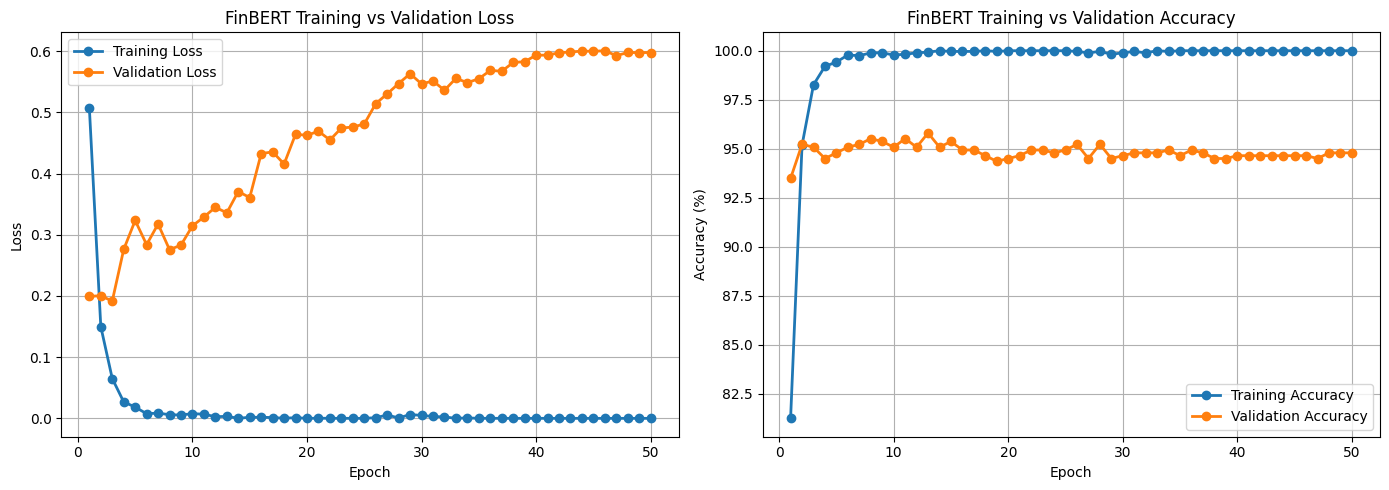


Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91        84
     Neutral       0.97      0.96      0.96       429
    Positive       0.92      0.93      0.92       178

    accuracy                           0.95       691
   macro avg       0.93      0.94      0.93       691
weighted avg       0.95      0.95      0.95       691



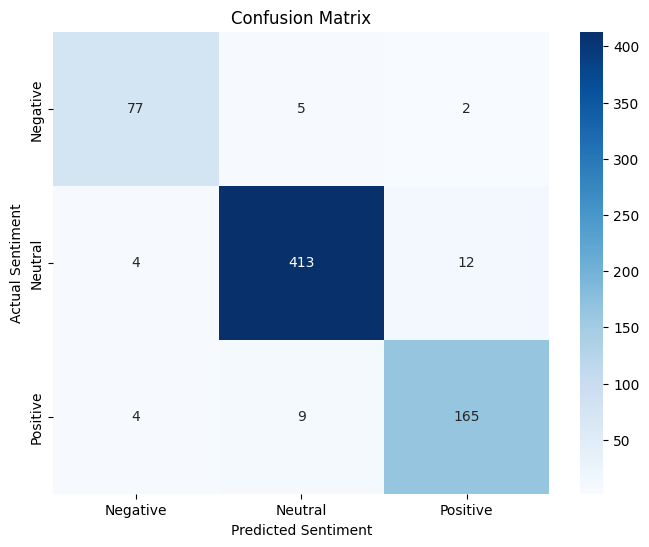


Final Accuracy: 94.79%
Final Weighted F1 Score: 0.9480


In [3]:
# ============================================================
# FINBERT SENTIMENT ANALYSIS (FULL VERSION)
# WITH TRAINING vs VALIDATION ACCURACY & LOSS
# ============================================================

# !pip install transformers torch pandas numpy matplotlib seaborn scikit-learn

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

import torch
import torch.nn as nn
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    RandomSampler,
    SequentialSampler
)

from torch.optim import AdamW

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

# ============================================================
# 1. LOAD FINANCIAL PHRASEBANK DATASET
# ============================================================

# Dataset format:
# sentence @ label

texts = []
labels = []

with open(
    "Sentences_75Agree.txt",
    "r",
    encoding="latin-1"
) as file:

    for line in file:

        line = line.strip()

        if "@" in line: # Changed from "@ " to "@"

            sentence, label = line.rsplit("@", 1)

            texts.append(sentence.strip())
            labels.append(label.strip())

# Create dataframe
data = pd.DataFrame({
    "Text": texts,
    "Sentiment": labels
})

print("Dataset Shape:", data.shape)
print(data.head())

# ============================================================
# 2. LABEL ENCODING
# ============================================================

label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

data["Sentiment"] = data["Sentiment"].map(label_mapping)

# ============================================================
# 3. PREPROCESSING
# ============================================================

def preprocess_text(data):

    data['Text_Cleaned'] = data['Text'].astype(str).str.lower()

    # Remove URLs
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'http\S+|www\S+|https\S+',
        '',
        regex=True
    )

    # Remove special characters
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'[^a-zA-Z0-9\s]',
        '',
        regex=True
    )

    # Remove extra spaces
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'\s+',
        ' ',
        regex=True
    )

    data['Text_Cleaned'] = data['Text_Cleaned'].str.strip()

    return data

data = preprocess_text(data)

# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X = data['Text_Cleaned'].values
y = data['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 5. TOKENIZATION
# ============================================================

FINBERT_MODEL = "ProsusAI/finbert"

tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL)

MAX_LEN = 128

def preprocessing_for_bert(data_col):

    input_ids = []
    attention_masks = []

    for text in data_col:

        encoding = tokenizer(
            text=text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )

        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)

    return input_ids, attention_masks

print("\nTokenizing Data...")

X_train_inputs, X_train_masks = preprocessing_for_bert(X_train)
X_test_inputs, X_test_masks = preprocessing_for_bert(X_test)

y_train_labels = torch.tensor(y_train)
y_test_labels = torch.tensor(y_test)

# ============================================================
# 6. DATALOADERS
# ============================================================

batch_size = 16

train_data = TensorDataset(
    X_train_inputs,
    X_train_masks,
    y_train_labels
)

train_sampler = RandomSampler(train_data)

train_dataloader = DataLoader(
    train_data,
    sampler=train_sampler,
    batch_size=batch_size
)

test_data = TensorDataset(
    X_test_inputs,
    X_test_masks,
    y_test_labels
)

test_sampler = SequentialSampler(test_data)

test_dataloader = DataLoader(
    test_data,
    sampler=test_sampler,
    batch_size=batch_size
)

# ============================================================
# 7. MODEL
# ============================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("\nUsing Device:", device)

model = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL,
    num_labels=3,
    ignore_mismatched_sizes=True
)

model.to(device)

# ============================================================
# 8. TRAINING SETUP
# ============================================================

epochs = 50

learning_rate = 2e-5
epsilon = 1e-8

optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    eps=epsilon
)

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ============================================================
# 9. TRAINING LOOP
# ============================================================

train_loss_history = []
test_loss_history = []

train_acc_history = []
test_acc_history = []

f1_history = []

best_accuracy = 0

print("\nStarting FinBERT Training...\n")

for epoch in range(epochs):

    print(f"======== Epoch {epoch+1}/{epochs} ========")

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    total_train_loss = 0

    train_predictions = []
    train_true_labels = []

    for batch in train_dataloader:

        batch_inputs, batch_masks, batch_labels = batch

        batch_inputs = batch_inputs.to(device)
        batch_masks = batch_masks.to(device)
        batch_labels = batch_labels.to(device)

        model.zero_grad()

        outputs = model(
            input_ids=batch_inputs,
            attention_mask=batch_masks,
            labels=batch_labels
        )

        loss = outputs.loss
        logits = outputs.logits

        total_train_loss += loss.item()

        preds = torch.argmax(logits, dim=1).flatten()

        train_predictions.extend(preds.cpu().numpy())
        train_true_labels.extend(batch_labels.cpu().numpy())

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)

    train_accuracy = accuracy_score(
        train_true_labels,
        train_predictions
    ) * 100

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    total_test_loss = 0

    predictions = []
    true_labels = []

    for batch in test_dataloader:

        batch_inputs, batch_masks, batch_labels = batch

        batch_inputs = batch_inputs.to(device)
        batch_masks = batch_masks.to(device)
        batch_labels = batch_labels.to(device)

        with torch.no_grad():

            outputs = model(
                input_ids=batch_inputs,
                attention_mask=batch_masks,
                labels=batch_labels
            )

        loss = outputs.loss
        logits = outputs.logits

        total_test_loss += loss.item()

        preds = torch.argmax(logits, dim=1).flatten()

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch_labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader)

    validation_accuracy = accuracy_score(
        true_labels,
        predictions
    ) * 100

    weighted_f1 = f1_score(
        true_labels,
        predictions,
        average='weighted'
    )

    # ========================================================
    # STORE HISTORY
    # ========================================================

    train_loss_history.append(avg_train_loss)
    test_loss_history.append(avg_test_loss)

    train_acc_history.append(train_accuracy)
    test_acc_history.append(validation_accuracy)

    f1_history.append(weighted_f1)

    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_test_loss:.4f}")

    print(f"Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Accuracy: {validation_accuracy:.2f}%")

    print(f"F1 Score: {weighted_f1:.4f}\n")

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if validation_accuracy > best_accuracy:

        best_accuracy = validation_accuracy

        torch.save(
            model.state_dict(),
            "best_finbert_model.pt"
        )

        print("Best model saved.\n")

# ============================================================
# 10. SAVE MODEL & TOKENIZER
# ============================================================

model.save_pretrained("finbert_complete_model")
tokenizer.save_pretrained("finbert_tokenizer")

print("\nModel and tokenizer saved successfully.")

# ============================================================
# 11. VISUALIZATION
# ============================================================

epochs_range = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(14, 5))

# ============================================================
# LOSS GRAPH
# ============================================================

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    train_loss_history,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs_range,
    test_loss_history,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title('FinBERT Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()
plt.grid(True)

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    train_acc_history,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    test_acc_history,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title('FinBERT Training vs Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        true_labels,
        predictions,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

# ============================================================
# 14. FINAL METRICS
# ============================================================

final_accuracy = accuracy_score(
    true_labels,
    predictions
) * 100

final_f1 = f1_score(
    true_labels,
    predictions,
    average='weighted'
)

print(f"\nFinal Accuracy: {final_accuracy:.2f}%")
print(f"Final Weighted F1 Score: {final_f1:.4f}")
